NOTEBOOK 5: DBSCAN Outlier Detection
Run AFTER Notebook 4 is complete.
 
Inputs:
    - analytical_dataset.csv
    - hypothesis_results.csv
 
Outputs:
    - ticker_sectors.csv              (sector lookup — pulled once from yfinance)
    - politician_profiles.csv         (one row per politician, all DBSCAN features)
    - dbscan_results.csv              (clustering labels + outlier tier)
    - convergence_politicians.csv     (politicians flagged by BOTH Wilcoxon + DBSCAN)
 
Methodology:
    - Spark for data loading and aggregation
    - yfinance for sector enrichment (run once, cached to disk)
    - sklearn DBSCAN with epsilon from k-distance elbow plot
    - PCA 2D projection for visualisation

# CELL 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import time
from pathlib import Path

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import yfinance as yf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# CONFIG (OS-independent paths)
OUTPUT_DIR = Path("data") / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYTICAL_PATH = OUTPUT_DIR / "analytical_dataset.csv"
HYPOTHESIS_PATH = OUTPUT_DIR / "hypothesis_results.csv"
SECTORS_PATH    = OUTPUT_DIR / "ticker_sectors.csv"
PROFILES_PATH   = OUTPUT_DIR / "politician_profiles.csv"
DBSCAN_OUT      = OUTPUT_DIR / "dbscan_results.csv"
CONVERGENCE_OUT = OUTPUT_DIR / "convergence_politicians.csv"

MIN_TRADES_DBSCAN  = 10   # lower than Wilcoxon — DBSCAN works on profiles
                        # not individual trades so 10 is okay
DBSCAN_MIN_SAMPLES = 5    # minimum cluster size

# Committee → sector mapping
# Based on publicly available committee jurisdiction information
COMMITTEE_SECTOR_MAP = {
    'Armed Services':          ['Industrials', 'Aerospace & Defense'],
    'Financial Services':      ['Financials', 'Financial Services'],
    'Energy and Commerce':     ['Energy', 'Utilities', 'Healthcare'],
    'Science and Technology':  ['Technology', 'Communication Services'],
    'Agriculture':             ['Consumer Staples', 'Materials'],
    'Transportation':          ['Industrials', 'Energy'],
    'Judiciary':               [],
    'Foreign Affairs':         ['Energy', 'Industrials'],
    'Intelligence':            ['Technology', 'Industrials'],
    'Finance':                 ['Financials', 'Financial Services'],
    'Banking':                 ['Financials', 'Financial Services'],
    'Commerce':                ['Technology', 'Communication Services',
                                'Consumer Discretionary'],
    'Health':                  ['Healthcare'],
    'Environment':             ['Energy', 'Utilities', 'Materials'],
}

print("All imports loaded successfully")

All imports loaded successfully


# CELL 2 — Start Spark & Load Data

Run this cell below if Cell 2 fails. Or to play safe, just run this cell together.

In [2]:
import os

# 1. Update package lists so it can find the packages
!sudo apt-get update -qq

# 2. Install Java 17 instead of 11
!sudo apt-get install openjdk-17-jdk-headless -qq > /dev/null

# 3. Set the JAVA_HOME environment variable to the Java 17 path
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [3]:
spark = SparkSession.builder \
    .appName("SC2320_Project_Group6_DBSCAN") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
 
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")
 
# Load analytical dataset
sdf = spark.read.csv(str(ANALYTICAL_PATH), header=True, inferSchema=True)
print(f"Analytical dataset: {sdf.count():,} rows")
 
# Load hypothesis results
hyp_df = pd.read_csv(HYPOTHESIS_PATH)
print(f"Hypothesis results: {len(hyp_df):,} politicians")
 
# Significant politicians from Notebook 4
sig_politicians = set(
    hyp_df[hyp_df['significant'] == True]['politician'].tolist()
)
print(f"Significant politicians from Notebook 4: {len(sig_politicians)}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/21 14:46:54 WARN Utils: Your hostname, codespaces-a752f8, resolves to a loopback address: 127.0.0.1; using 10.0.13.103 instead (on interface eth0)
26/04/21 14:46:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 14:46:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/21 14:46:56 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


Analytical dataset: 24,130 rows
Hypothesis results: 75 politicians
Significant politicians from Notebook 4: 12


# CELL 3 — Pull Sector Data from yfinance (run once, cached)

In [4]:
print("=" * 60)
print("SECTOR ENRICHMENT via yfinance")
print("=" * 60)
 
if os.path.exists(SECTORS_PATH):
    print(f"Cached sector file found — loading {SECTORS_PATH}")
    sectors_df = pd.read_csv(SECTORS_PATH)
else:
    print("No cache found — pulling sectors from yfinance...")
    print("This runs once only and saves to disk.\n")
 
    # Get unique tickers from analytical dataset
    tickers_pdf = sdf.select('ticker').distinct().toPandas()
    unique_tickers = tickers_pdf['ticker'].dropna().unique().tolist()
    print(f"Unique tickers to enrich: {len(unique_tickers):,}")
 
    sector_records = []
    failed_tickers = []
 
    for i, ticker in enumerate(unique_tickers):
        if i % 100 == 0:
            print(f"  [{i:>4}/{len(unique_tickers)}] processing...")
        try:
            info   = yf.Ticker(ticker).info
            sector = info.get('sector', 'Unknown')
            industry = info.get('industry', 'Unknown')
            sector_records.append({
                'ticker':   ticker,
                'sector':   sector if sector else 'Unknown',
                'industry': industry if industry else 'Unknown',
            })
        except Exception:
            failed_tickers.append(ticker)
            sector_records.append({
                'ticker':   ticker,
                'sector':   'Unknown',
                'industry': 'Unknown',
            })
        time.sleep(0.3)   # polite delay
 
    sectors_df = pd.DataFrame(sector_records)
    sectors_df.to_csv(SECTORS_PATH, index=False)
    print(f"\nSectors saved to {SECTORS_PATH}")
    print(f"Failed tickers: {len(failed_tickers)}")
 
# Replace Unknown/None with 'Other'
sectors_df['sector'] = sectors_df['sector'].fillna('Other')
sectors_df.loc[sectors_df['sector'] == 'Unknown', 'sector'] = 'Other'
 
print(f"\nSector distribution:")
print(sectors_df['sector'].value_counts().to_string())

SECTOR ENRICHMENT via yfinance
No cache found — pulling sectors from yfinance...
This runs once only and saves to disk.



Unique tickers to enrich: 1,521
  [   0/1521] processing...
  [ 100/1521] processing...
  [ 200/1521] processing...
  [ 300/1521] processing...
  [ 400/1521] processing...
  [ 500/1521] processing...
  [ 600/1521] processing...
  [ 700/1521] processing...
  [ 800/1521] processing...
  [ 900/1521] processing...
  [1000/1521] processing...
  [1100/1521] processing...
  [1200/1521] processing...
  [1300/1521] processing...
  [1400/1521] processing...
  [1500/1521] processing...

Sectors saved to data/output/ticker_sectors.csv
Failed tickers: 0

Sector distribution:
sector
Industrials               258
Financial Services        241
Technology                227
Consumer Cyclical         190
Healthcare                186
Consumer Defensive         95
Basic Materials            78
Communication Services     72
Energy                     69
Utilities                  56
Real Estate                43
Other                       6


# CELL 4 — Spark: Merge Sector Into Analytical Dataset

In [5]:
# Upload sectors to Spark
sectors_spark = spark.createDataFrame(sectors_df[['ticker', 'sector']])
 
# Join sector onto analytical dataset
sdf_enriched = sdf.join(sectors_spark, on='ticker', how='left')
sdf_enriched = sdf_enriched.fillna({'sector': 'Other'})
 
print(f"Enriched dataset rows: {sdf_enriched.count():,}")
sdf_enriched.select('politician', 'ticker', 'sector',
                    'abn_ret_mean', 'anomaly_flag_L1').show(5, truncate=False)

Enriched dataset rows: 24,130
+-----------+------+----------------------+------------+---------------+
|politician |ticker|sector                |abn_ret_mean|anomaly_flag_L1|
+-----------+------+----------------------+------------+---------------+
|Adam Schiff|AAPL  |Technology            |0.17036     |0              |
|Angus King |VZ    |Communication Services|0.27817     |0              |
|Angus King |VZ    |Communication Services|-0.068422   |0              |
|Angus King |AMD   |Technology            |0.093126    |0              |
|Angus King |EA    |Communication Services|-0.040559   |0              |
+-----------+------+----------------------+------------+---------------+
only showing top 5 rows


# CELL 5 — Spark: Aggregate Into Politician Profiles

In [6]:
print("=" * 60)
print("SPARK: Building politician profiles")
print("=" * 60)
 
# Filter to politicians with enough trades
trade_counts = sdf_enriched.groupBy('politician').count()
qualifying   = trade_counts.filter(F.col('count') >= MIN_TRADES_DBSCAN)
qual_names   = [r['politician'] for r in qualifying.select('politician').collect()]
 
sdf_qual = sdf_enriched.filter(F.col('politician').isin(qual_names))
print(f"Politicians with >= {MIN_TRADES_DBSCAN} trades: {len(qual_names)}")
 
# ── Feature 1–3: Core AbnRet + Anomaly + Disclosure ─────────
base_agg = sdf_qual.groupBy('politician').agg(
    F.count('*').alias('n_trades'),
    F.first('party').alias('party'),
    F.first('chamber').alias('chamber'),
    F.first('state').alias('state'),
    F.mean('abn_ret_mean').alias('avg_abn_ret_blind'),
    F.mean('ctrl_abn_ret_mean').alias('avg_abn_ret_ctrl'),
    F.mean('anomaly_flag_L1').alias('pct_l1_anomaly'),
    F.mean('anomaly_flag_L2').alias('pct_l2_anomaly'),
    F.mean('filed_after_days').alias('avg_filed_after_days'),
    F.mean('sigma_30').alias('avg_sigma_30'),
    F.mean('abn_ret_max').alias('avg_abn_ret_max'),
)
 
base_pdf = base_agg.toPandas()
print(f"Base profiles built for {len(base_pdf)} politicians")

SPARK: Building politician profiles


Politicians with >= 10 trades: 83


Base profiles built for 83 politicians


# CELL 6 — Compute Sector Concentration Features

In [7]:
# These features require per-politician sector distributions
# which are easier to compute in pandas after Spark aggregation
 
print("Computing sector concentration features...")
 
# Convert enriched data to pandas for sector computation
enriched_pdf = sdf_qual.select(
    'politician', 'ticker', 'sector', 'trade_type'
).toPandas()
 
sector_features = []
 
for politician, group in enriched_pdf.groupby('politician'):
    total = len(group)
 
    # Top sector concentration: % of trades in most common sector
    sector_counts = group['sector'].value_counts()
    top_sector       = sector_counts.index[0] if len(sector_counts) > 0 else 'Other'
    top_sector_pct   = sector_counts.iloc[0] / total if len(sector_counts) > 0 else 0
 
    # Sector diversity: number of distinct sectors traded
    # Lower = more concentrated = more suspicious
    n_sectors = group['sector'].nunique()
 
    # HHI (Herfindahl-Hirschman Index) of sector distribution
    # HHI = sum of squared market shares
    # 1.0 = perfectly concentrated, ~0 = perfectly diversified
    sector_pcts = sector_counts / total
    hhi = (sector_pcts ** 2).sum()
 
    sector_features.append({
        'politician':          politician,
        'top_sector':          top_sector,
        'top_sector_pct':      round(top_sector_pct, 4),
        'n_sectors_traded':    n_sectors,
        'sector_hhi':          round(hhi, 4),
    })
 
sector_pdf = pd.DataFrame(sector_features)
print(f"Sector features computed for {len(sector_pdf)} politicians")

Computing sector concentration features...
Sector features computed for 83 politicians


# CELL 7 — Committee-Sector Alignment Score

In [8]:
# For each politician, compute what fraction of their trades
# are in sectors their committee oversees.
# This is the most analytically powerful feature.
 
print("Computing committee-sector alignment scores...")
 
# We derive committee from the hypothesis results if available
# Otherwise we approximate from party + chamber + state patterns
# NOTE: Capitol Trades does not always include committee data
# so we use a best-effort mapping from known committee assignments
 
# Load hypothesis results which may have committee info
hyp_pdf = pd.read_csv(HYPOTHESIS_PATH)
 
alignment_scores = []
 
for politician, group in enriched_pdf.groupby('politician'):
    total = len(group)
 
    # Get politician metadata
    pol_row = hyp_pdf[hyp_pdf['politician'] == politician]
 
    # Try to find committee from hypothesis results
    committee = None
    if len(pol_row) > 0 and 'committee' in pol_row.columns:
        committee = pol_row['committee'].iloc[0]
 
    if committee and not pd.isna(committee):
        # Get sectors this committee oversees
        overseen_sectors = []
        for comm_key, sectors in COMMITTEE_SECTOR_MAP.items():
            if comm_key.lower() in str(committee).lower():
                overseen_sectors.extend(sectors)
 
        if overseen_sectors:
            # What fraction of their trades are in overseen sectors?
            aligned_trades = group[group['sector'].isin(overseen_sectors)]
            alignment_score = len(aligned_trades) / total
        else:
            alignment_score = 0.0
    else:
        # No committee data — use neutral score
        alignment_score = np.nan
 
    alignment_scores.append({
        'politician':              politician,
        'committee_alignment':     round(alignment_score, 4),
    })
 
alignment_pdf = pd.DataFrame(alignment_scores)
print(f"Alignment scores computed. "
      f"Non-null: {alignment_pdf['committee_alignment'].notna().sum()}")
 

Computing committee-sector alignment scores...
Alignment scores computed. Non-null: 0


# CELL 8 — Merge All Features Into Politician Profiles

In [9]:
profiles = base_pdf \
    .merge(sector_pdf,    on='politician', how='left') \
    .merge(alignment_pdf, on='politician', how='left')
 
# Fill missing committee alignment with median
# (neutral assumption when committee data unavailable)
median_alignment = profiles['committee_alignment'].median()
profiles['committee_alignment'] = profiles['committee_alignment'].fillna(
    median_alignment if not np.isnan(median_alignment) else 0.0
)
 
# Merge in hypothesis testing results
profiles = profiles.merge(
    hyp_pdf[['politician', 'p_value_bh', 'significant',
              'median_blind_abn_ret', 'median_ctrl_abn_ret']],
    on='politician',
    how='left'
)
profiles['significant'] = profiles['significant'].fillna(False)
 
print(f"Final profiles shape: {profiles.shape}")
print(f"\nProfile columns:")
for col in profiles.columns:
    nulls = profiles[col].isna().sum()
    print(f"  {col:<35} nulls: {nulls}")
 
profiles.to_csv(PROFILES_PATH, index=False)
print(f"\nProfiles saved to {PROFILES_PATH}")
 

Final profiles shape: (83, 21)

Profile columns:
  politician                          nulls: 0
  n_trades                            nulls: 0
  party                               nulls: 1
  chamber                             nulls: 1
  state                               nulls: 1
  avg_abn_ret_blind                   nulls: 0
  avg_abn_ret_ctrl                    nulls: 0
  pct_l1_anomaly                      nulls: 0
  pct_l2_anomaly                      nulls: 0
  avg_filed_after_days                nulls: 0
  avg_sigma_30                        nulls: 0
  avg_abn_ret_max                     nulls: 0
  top_sector                          nulls: 0
  top_sector_pct                      nulls: 0
  n_sectors_traded                    nulls: 0
  sector_hhi                          nulls: 0
  committee_alignment                 nulls: 0
  p_value_bh                          nulls: 8
  significant                         nulls: 0
  median_blind_abn_ret                nulls: 8
  median_ct

# CELL 9 — Prepare DBSCAN Feature Matrix

In [10]:
print("=" * 60)
print("PREPARING DBSCAN FEATURE MATRIX")
print("=" * 60)
 
# Final DBSCAN feature set
DBSCAN_FEATURES = [
    'avg_abn_ret_blind',      # Overall return anomaly magnitude
    'pct_l1_anomaly',         # How often trades hit anomalous days
    'avg_filed_after_days',   # Disclosure speed
    'top_sector_pct',         # Sector concentration
    'sector_hhi',             # Sector diversity (HHI)
    'committee_alignment',    # Trades in committee-overseen sectors
]
 
X_raw = profiles[DBSCAN_FEATURES].copy()
 
# Drop rows with any remaining NaN in feature columns
valid_mask = X_raw.notna().all(axis=1)
X_clean    = X_raw[valid_mask].copy()
profiles_clean = profiles[valid_mask].copy().reset_index(drop=True)
 
print(f"Politicians in feature matrix : {len(X_clean)}")
print(f"Politicians dropped (NaN)     : {(~valid_mask).sum()}")
print(f"\nFeature statistics:")
print(X_clean.describe().round(4).to_string())
 
# Standardise to zero mean, unit variance
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
 
print(f"\nFeatures standardised. Shape: {X_scaled.shape}")

PREPARING DBSCAN FEATURE MATRIX
Politicians in feature matrix : 83
Politicians dropped (NaN)     : 0

Feature statistics:
       avg_abn_ret_blind  pct_l1_anomaly  avg_filed_after_days  top_sector_pct  sector_hhi  committee_alignment
count            83.0000         83.0000               83.0000         83.0000     83.0000                 83.0
mean             -0.0064          0.4241               47.2015          0.3449      0.2398                  0.0
std               0.1096          0.2056               50.9954          0.1908      0.1856                  0.0
min              -0.2678          0.0732                6.2258          0.1723      0.1160                  0.0
25%              -0.0544          0.2753               23.1966          0.2197      0.1417                  0.0
50%              -0.0128          0.3906               30.0217          0.2793      0.1719                  0.0
75%               0.0329          0.5495               35.1090          0.3863      0.2498    

# CELL 10 — Find Optimal Epsilon via k-Distance Elbow Plot

Computing k-distance plot for epsilon selection...


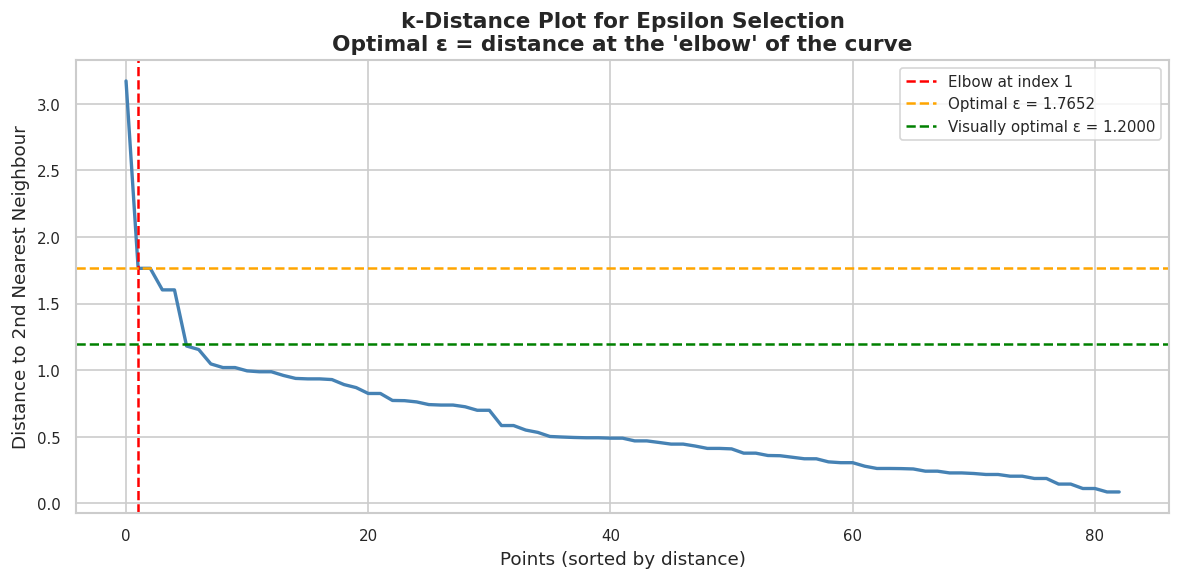


Automatically detected optimal epsilon: 1.7652
You can manually override this below if the elbow looks different visually.
Using epsilon = 1.2000


In [23]:
print("Computing k-distance plot for epsilon selection...")
 
k = 2   # DBSCAN_MIN_SAMPLES - 1 is conventional but k=2 works well here
nbrs    = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
 
# Sort distances to 2nd nearest neighbour
k_distances = np.sort(distances[:, k-1])[::-1]
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances,
        color='steelblue', linewidth=2)
ax.set_xlabel("Points (sorted by distance)")
ax.set_ylabel(f"Distance to {k}nd Nearest Neighbour")
ax.set_title("k-Distance Plot for Epsilon Selection\n"
             "Optimal ε = distance at the 'elbow' of the curve",
             fontweight='bold')
 
# Find elbow automatically using maximum curvature
# Compute second derivative to find the sharpest bend
diffs1 = np.diff(k_distances)
diffs2 = np.diff(diffs1)
elbow_idx = np.argmax(np.abs(diffs2)) + 1
optimal_eps = k_distances[elbow_idx]
visually_optimal_eps = 1.2   # based on visual inspection of the plot
 
ax.axvline(elbow_idx, color='red', linestyle='--', linewidth=1.5,
           label=f'Elbow at index {elbow_idx}')
ax.axhline(optimal_eps, color='orange', linestyle='--', linewidth=1.5,
           label=f'Optimal ε = {optimal_eps:.4f}')
ax.axhline(visually_optimal_eps, color='green', linestyle='--', linewidth=1.5,
           label=f'Visually optimal ε = {visually_optimal_eps:.4f}')
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("chart0_elbow_plot.png", bbox_inches='tight', dpi=150)
plt.show()
 
print(f"\nAutomatically detected optimal epsilon: {optimal_eps:.4f}")
print(f"You can manually override this below if the elbow looks different visually.")
 
# ── MANUAL OVERRIDE
# If the elbow plot suggests a different value, can set it here:
EPSILON = visually_optimal_eps   # change this if needed after visual inspection
print(f"Using epsilon = {EPSILON:.4f}")

# CELL 11 — Run DBSCAN

In [24]:
print("=" * 60)
print(f"RUNNING DBSCAN")
print(f"  epsilon     = {EPSILON:.4f}")
print(f"  min_samples = {DBSCAN_MIN_SAMPLES}")
print("=" * 60)
 
dbscan = DBSCAN(eps=EPSILON, min_samples=DBSCAN_MIN_SAMPLES)
labels = dbscan.fit_predict(X_scaled)
 
profiles_clean['dbscan_label'] = labels
 
# Classify each politician
def classify_label(label):
    if label == -1:
        return 'Outlier'
    elif label == 0:
        return 'Core Cluster A'
    else:
        return f'Core Cluster {chr(65 + label)}'
 
profiles_clean['cluster_type'] = profiles_clean['dbscan_label'].apply(classify_label)
 
# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = (labels == -1).sum()
n_noise_pct = n_outliers / len(labels) * 100
 
print(f"\nClusters found          : {n_clusters}")
print(f"Outliers (label = -1)   : {n_outliers} ({n_noise_pct:.1f}%)")
print(f"\nCluster distribution:")
label_counts = pd.Series(labels).value_counts().sort_index()
for label, count in label_counts.items():
    label_name = 'OUTLIER TIER' if label == -1 else f'Cluster {label}'
    print(f"  {label_name:<20} : {count:>3} politicians")

RUNNING DBSCAN
  epsilon     = 1.2000
  min_samples = 5

Clusters found          : 1
Outliers (label = -1)   : 15 (18.1%)

Cluster distribution:
  OUTLIER TIER         :  15 politicians
  Cluster 0            :  68 politicians


# CELL 12 — Identify Outlier Tier

In [25]:
outliers = profiles_clean[profiles_clean['dbscan_label'] == -1].copy()
outliers = outliers.sort_values('avg_abn_ret_blind', ascending=False)
 
print("=" * 60)
print("OUTLIER TIER — DBSCAN noise points")
print("=" * 60)
print(f"\n{len(outliers)} politicians in the Outlier Tier:\n")
 
display_cols = ['politician', 'party', 'chamber', 'n_trades',
                'avg_abn_ret_blind', 'pct_l1_anomaly',
                'avg_filed_after_days', 'top_sector',
                'top_sector_pct', 'significant']
 
print(outliers[display_cols].to_string(index=False))
 

OUTLIER TIER — DBSCAN noise points

15 politicians in the Outlier Tier:

     politician      party chamber  n_trades  avg_abn_ret_blind  pct_l1_anomaly  avg_filed_after_days         top_sector  top_sector_pct significant
 John Fetterman   Democrat  Senate        10           0.545482        0.300000             10.400000         Technology          0.3000       False
    Blake Moore Republican   House        31           0.383471        0.161290              6.225806         Technology          0.2258        True
  Emily Randall   Democrat   House        11           0.128774        0.818182             36.909091         Healthcare          0.2727       False
   Austin Scott Republican   House        19           0.031943        0.842105            205.578947        Industrials          0.7368       False
     Dan Meuser Republican   House        20           0.029334        1.000000            134.550000         Technology          0.7500       False
    Sheri Biggs Republican   Hous

# CELL 13 — Convergence Analysis. Politicians flagged by BOTH methods

In [26]:
print("=" * 60)
print("CONVERGENCE ANALYSIS")
print("Wilcoxon Significant ∩ DBSCAN Outlier Tier")
print("=" * 60)
 
# Politicians significant in Notebook 4
wilcoxon_sig = set(
    hyp_pdf[hyp_pdf['significant'] == True]['politician'].tolist()
)
 
# Politicians in DBSCAN outlier tier
dbscan_outliers = set(outliers['politician'].tolist())
 
# Intersection — flagged by BOTH
convergence = wilcoxon_sig & dbscan_outliers
 
# All categories
only_wilcoxon  = wilcoxon_sig - dbscan_outliers
only_dbscan    = dbscan_outliers - wilcoxon_sig
neither        = set(profiles_clean['politician']) - wilcoxon_sig - dbscan_outliers
 
print(f"\nWilcoxon significant only  : {len(only_wilcoxon)}")
print(f"DBSCAN outlier only        : {len(only_dbscan)}")
print(f"BOTH methods (convergence) : {len(convergence)}  ← STRONGEST FINDING")
print(f"Neither method             : {len(neither)}")
 
if len(convergence) > 0:
    conv_profiles = profiles_clean[
        profiles_clean['politician'].isin(convergence)
    ].sort_values('avg_abn_ret_blind', ascending=False)
 
    print(f"\nConvergence politicians (flagged by BOTH methods):")
    print(conv_profiles[display_cols + ['p_value_bh']].to_string(index=False))
 
    conv_profiles.to_csv(CONVERGENCE_OUT, index=False)
    print(f"\nSaved to {CONVERGENCE_OUT}")
else:
    print("\nNo politicians flagged by both methods.")
    print("This means DBSCAN found different outliers than Wilcoxon.")
    print("This is still a valid finding — discuss the methodological")
    print("difference in your report (Wilcoxon = per-politician test,")
    print("DBSCAN = relative to population distribution).")

CONVERGENCE ANALYSIS
Wilcoxon Significant ∩ DBSCAN Outlier Tier

Wilcoxon significant only  : 11
DBSCAN outlier only        : 14
BOTH methods (convergence) : 1  ← STRONGEST FINDING
Neither method             : 57

Convergence politicians (flagged by BOTH methods):
 politician      party chamber  n_trades  avg_abn_ret_blind  pct_l1_anomaly  avg_filed_after_days top_sector  top_sector_pct significant  p_value_bh
Blake Moore Republican   House        31           0.383471         0.16129              6.225806 Technology          0.2258        True    0.000025

Saved to data/output/convergence_politicians.csv


# CELL 14 — Chart 1 PCA 2D Scatter Plot


PCA explained variance: PC1=41.8%, PC2=31.7%, Total=73.4%


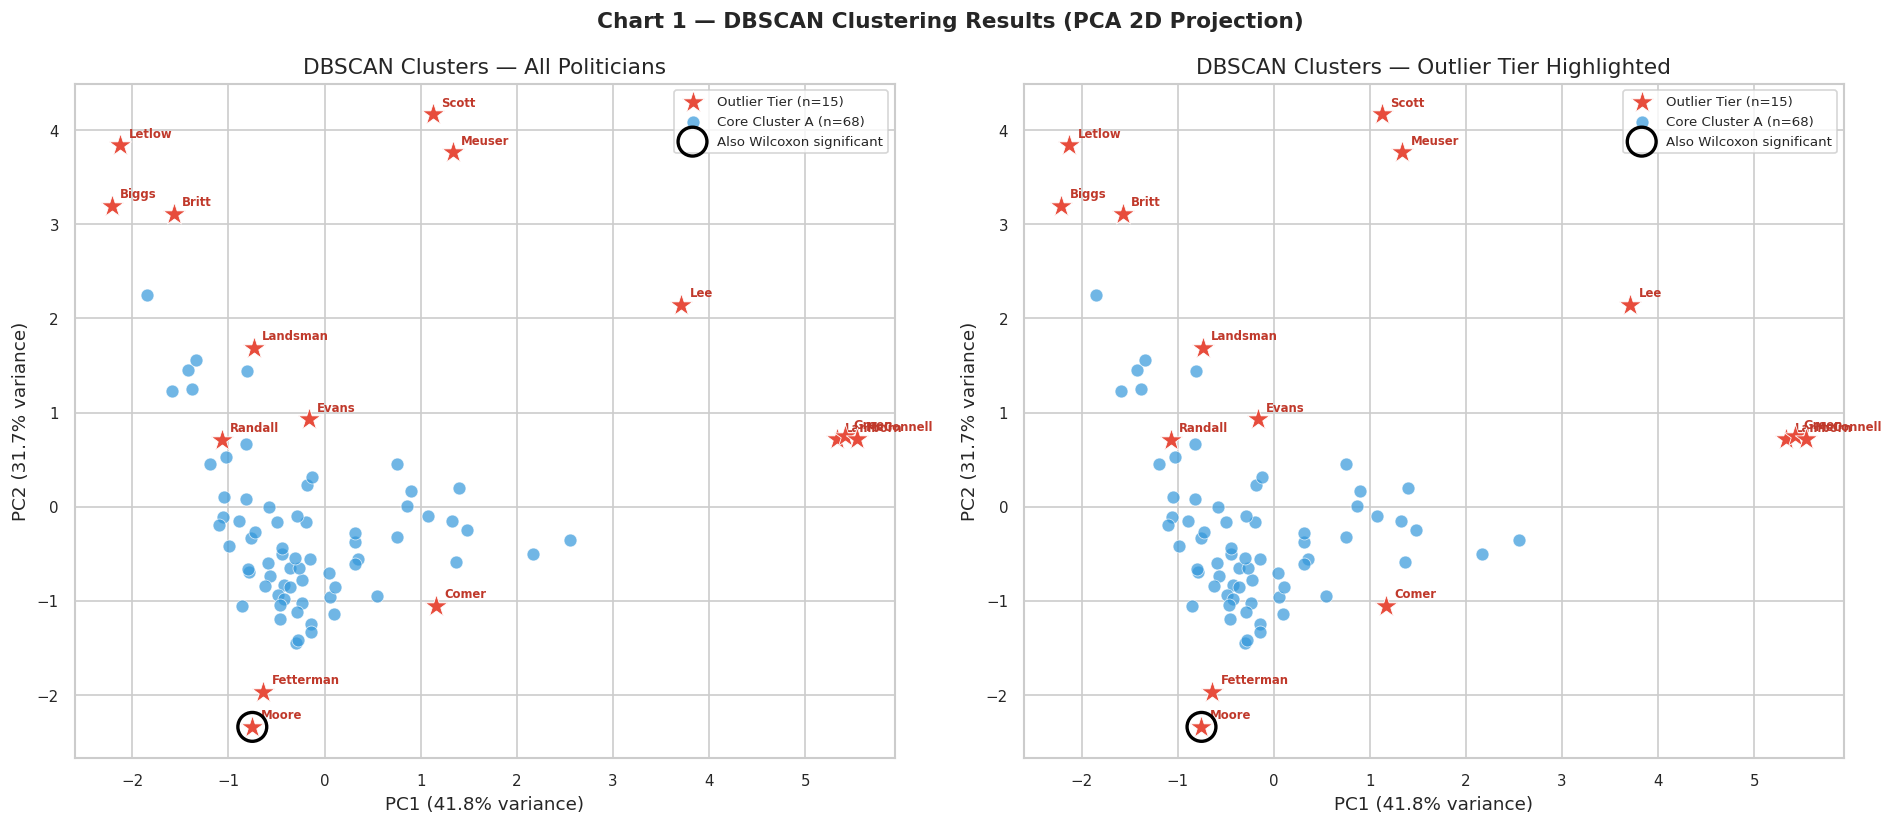

Chart 1 saved to: data/output/chart1_dbscan_pca.png


In [27]:
# Reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
profiles_clean['pca_1'] = X_pca[:, 0]
profiles_clean['pca_2'] = X_pca[:, 1]
 
explained = pca.explained_variance_ratio_
print(f"\nPCA explained variance: PC1={explained[0]:.1%}, "
      f"PC2={explained[1]:.1%}, "
      f"Total={sum(explained):.1%}")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Chart 1 — DBSCAN Clustering Results (PCA 2D Projection)",
             fontsize=13, fontweight='bold')
 
for ax_idx, (ax, title_suffix) in enumerate(
        zip(axes, ['All Politicians', 'Outlier Tier Highlighted'])):
 
    # Plot each cluster
    for label in sorted(profiles_clean['dbscan_label'].unique()):
        mask = profiles_clean['dbscan_label'] == label
        subset = profiles_clean[mask]
 
        if label == -1:
            color, marker, size, zorder, alpha = '#E74C3C', '*', 200, 5, 1.0
            lbl = f'Outlier Tier (n={mask.sum()})'
        elif label == 0:
            color, marker, size, zorder, alpha = '#3498DB', 'o', 60, 3, 0.7
            lbl = f'Core Cluster A (n={mask.sum()})'
        else:
            color, marker, size, zorder, alpha = '#2ECC71', 's', 60, 3, 0.7
            lbl = f'Cluster {chr(65+label)} (n={mask.sum()})'
 
        ax.scatter(subset['pca_1'], subset['pca_2'],
                   c=color, marker=marker, s=size,
                   zorder=zorder, alpha=alpha, label=lbl,
                   edgecolors='white', linewidths=0.5)
 
    # Annotate outlier names
    outlier_mask = profiles_clean['dbscan_label'] == -1
    for _, row in profiles_clean[outlier_mask].iterrows():
        ax.annotate(
            row['politician'].split()[-1],   # last name only to avoid clutter
            xy=(row['pca_1'], row['pca_2']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=7, color='#C0392B', fontweight='bold'
        )
 
    # Mark convergence politicians with a ring
    if len(convergence) > 0:
        conv_mask = profiles_clean['politician'].isin(convergence)
        conv_subset = profiles_clean[conv_mask]
        ax.scatter(conv_subset['pca_1'], conv_subset['pca_2'],
                   s=300, facecolors='none', edgecolors='black',
                   linewidths=2, zorder=6,
                   label='Also Wilcoxon significant')
 
    ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
    ax.set_title(f"DBSCAN Clusters — {title_suffix}")
    ax.legend(fontsize=8, loc='upper right')
 
plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart1_dbscan_pca.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 1 saved to: {out_path}")

# CELL 15 — Chart 2 Feature Profiles of Outliers vs Normal

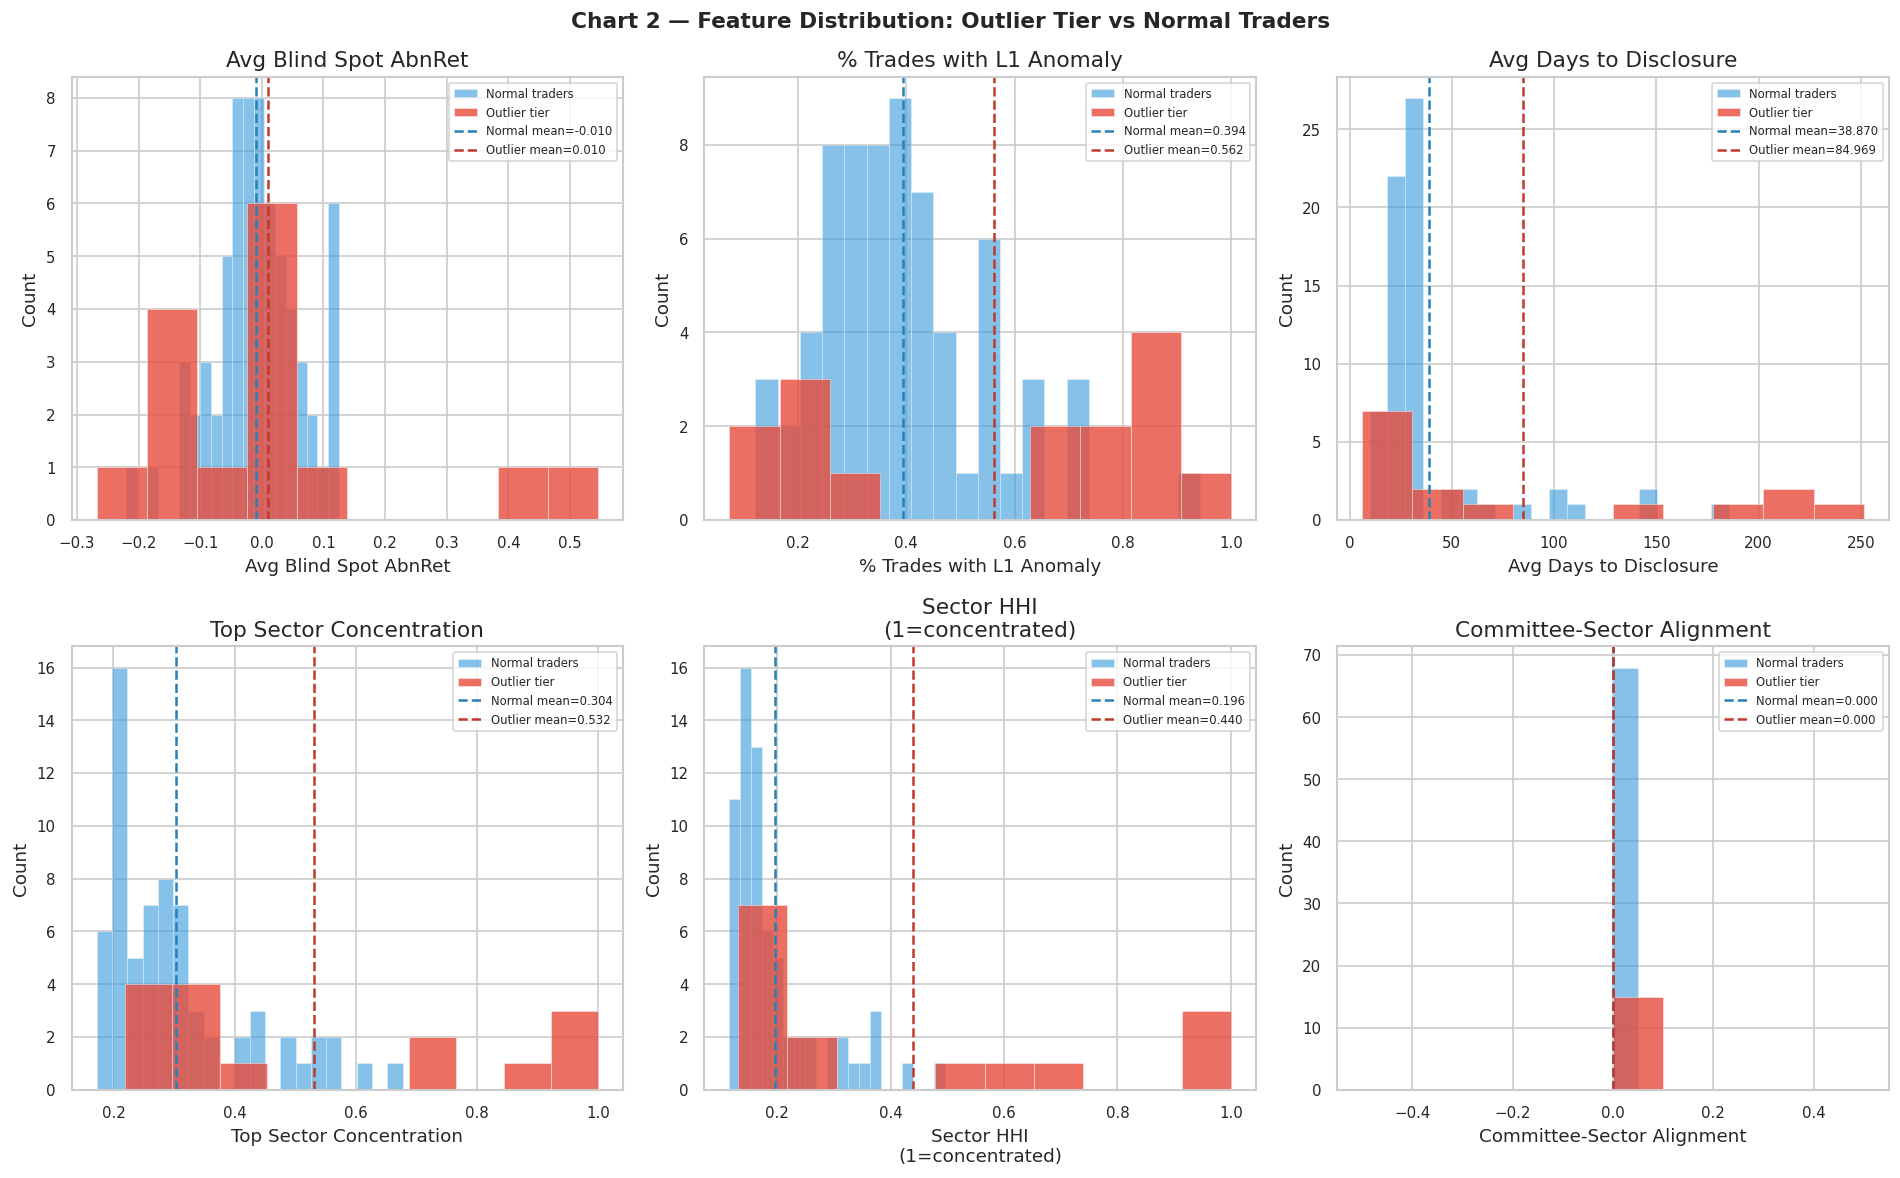

Chart 2 saved to: data/output/chart2_feature_profiles.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Chart 2 — Feature Distribution: Outlier Tier vs Normal Traders",
             fontsize=13, fontweight='bold')
axes = axes.flatten()
 
feature_labels = {
    'avg_abn_ret_blind':    'Avg Blind Spot AbnRet',
    'pct_l1_anomaly':       '% Trades with L1 Anomaly',
    'avg_filed_after_days': 'Avg Days to Disclosure',
    'top_sector_pct':       'Top Sector Concentration',
    'sector_hhi':           'Sector HHI\n(1=concentrated)',
    'committee_alignment':  'Committee-Sector Alignment',
}
 
for i, (feature, label) in enumerate(feature_labels.items()):
    ax = axes[i]
 
    normal_vals  = profiles_clean[
        profiles_clean['dbscan_label'] != -1][feature].dropna()
    outlier_vals = profiles_clean[
        profiles_clean['dbscan_label'] == -1][feature].dropna()
 
    ax.hist(normal_vals, bins=20, alpha=0.6,
            color='#3498DB', label='Normal traders',
            edgecolor='white', linewidth=0.3)
    ax.hist(outlier_vals, bins=10, alpha=0.8,
            color='#E74C3C', label='Outlier tier',
            edgecolor='white', linewidth=0.3)
 
    ax.axvline(normal_vals.mean(), color='#2980B9',
               linestyle='--', linewidth=1.5,
               label=f'Normal mean={normal_vals.mean():.3f}')
    ax.axvline(outlier_vals.mean(), color='#C0392B',
               linestyle='--', linewidth=1.5,
               label=f'Outlier mean={outlier_vals.mean():.3f}')
 
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(label)
    ax.legend(fontsize=7)

plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart2_feature_profiles.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 2 saved to: {out_path}")

# CELL 16 — Chart 3 Convergence Venn Diagram

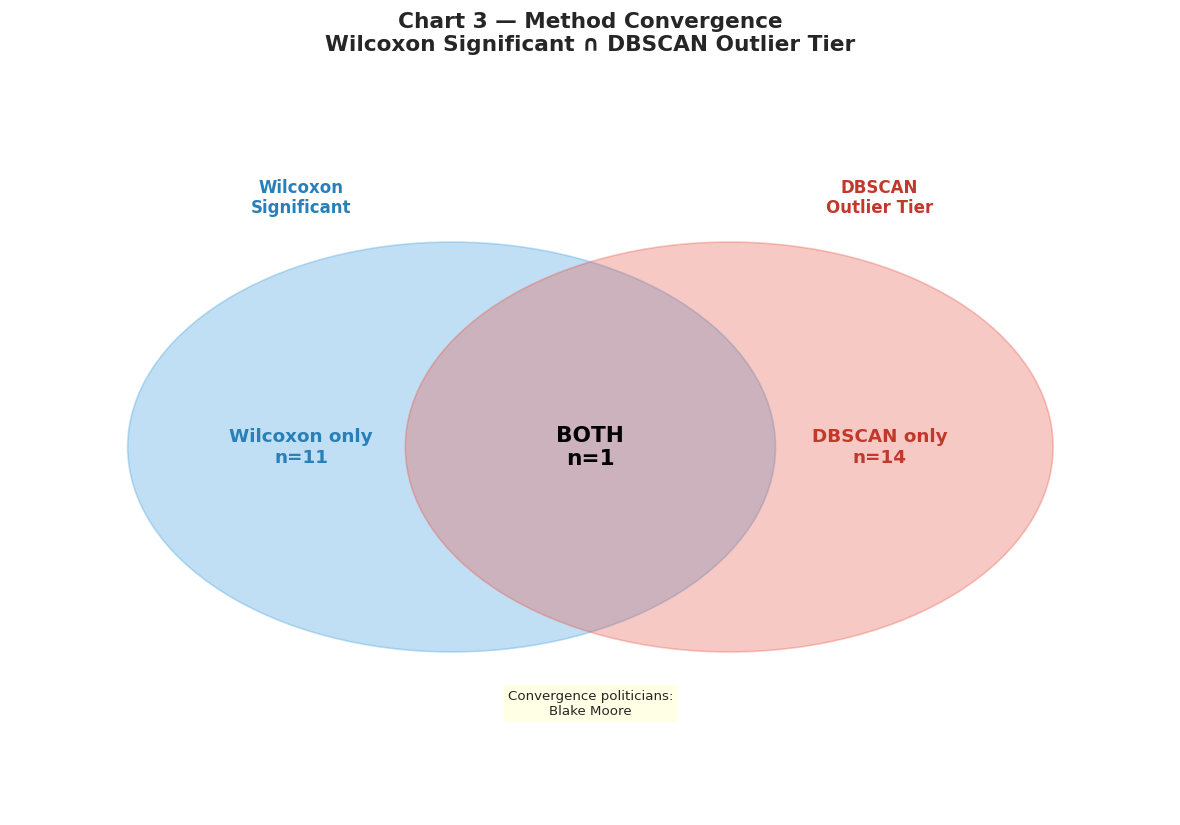

Chart 3 saved to: data/output/chart3_convergence_venn.png


In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Chart 3 — Method Convergence\n"
             "Wilcoxon Significant ∩ DBSCAN Outlier Tier",
             fontsize=13, fontweight='bold')
 
# Draw Venn manually using circles
from matplotlib.patches import Circle
 
circle_w = Circle((0.38, 0.5), 0.28,
                   fill=True, alpha=0.3, color='#3498DB')
circle_d = Circle((0.62, 0.5), 0.28,
                   fill=True, alpha=0.3, color='#E74C3C')
ax.add_patch(circle_w)
ax.add_patch(circle_d)
 
# Labels
ax.text(0.25, 0.5, f"Wilcoxon only\nn={len(only_wilcoxon)}",
        ha='center', va='center', fontsize=11,
        fontweight='bold', color='#2980B9')
ax.text(0.75, 0.5, f"DBSCAN only\nn={len(only_dbscan)}",
        ha='center', va='center', fontsize=11,
        fontweight='bold', color='#C0392B')
ax.text(0.50, 0.5, f"BOTH\nn={len(convergence)}",
        ha='center', va='center', fontsize=13,
        fontweight='bold', color='black')
 
# Circle titles
ax.text(0.25, 0.82, "Wilcoxon\nSignificant",
        ha='center', fontsize=10, color='#2980B9', fontweight='bold')
ax.text(0.75, 0.82, "DBSCAN\nOutlier Tier",
        ha='center', fontsize=10, color='#C0392B', fontweight='bold')
 
# List convergence names if any
if len(convergence) > 0:
    names = '\n'.join(sorted(convergence)[:8])
    ax.text(0.50, 0.15, f"Convergence politicians:\n{names}",
            ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow', alpha=0.8))
 
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')


plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart3_convergence_venn.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 3 saved to: {out_path}")

# CELL 17 — Save Final Results & Summary

In [32]:
# Save full DBSCAN results
profiles_clean.to_csv(DBSCAN_OUT, index=False)
print(f"Saved {DBSCAN_OUT} — {len(profiles_clean)} politicians")
 
print("=" * 60)
print("NOTEBOOK 5 — SUMMARY FOR REPORT")
print("=" * 60)
print(f"\nDBSCAN Configuration:")
print(f"  Features used    : {len(DBSCAN_FEATURES)}")
print(f"  Epsilon (ε)      : {EPSILON:.4f}")
print(f"  Min samples      : {DBSCAN_MIN_SAMPLES}")
print(f"  Politicians input: {len(profiles_clean)}")
print(f"\nClustering Results:")
print(f"  Clusters found   : {n_clusters}")
print(f"  Outlier tier     : {n_outliers} politicians ({n_noise_pct:.1f}%)")
print(f"\nConvergence (flagged by BOTH Wilcoxon + DBSCAN):")
print(f"  {len(convergence)} politicians — your STRONGEST finding")
if convergence:
    for name in sorted(convergence):
        row = profiles_clean[profiles_clean['politician'] == name].iloc[0]
        print(f"  → {name} | AbnRet={row['avg_abn_ret_blind']:.4f} | "
              f"L1={row['pct_l1_anomaly']:.1%} | "
              f"Sector={row['top_sector']} ({row['top_sector_pct']:.1%})")
 
print(f"\nNotebook 5 complete. Proceed to Notebook 6.")
 
spark.stop()

Saved data/output/dbscan_results.csv — 83 politicians
NOTEBOOK 5 — SUMMARY FOR REPORT

DBSCAN Configuration:
  Features used    : 6
  Epsilon (ε)      : 1.2000
  Min samples      : 5
  Politicians input: 83

Clustering Results:
  Clusters found   : 1
  Outlier tier     : 15 politicians (18.1%)

Convergence (flagged by BOTH Wilcoxon + DBSCAN):
  1 politicians — your STRONGEST finding
  → Blake Moore | AbnRet=0.3835 | L1=16.1% | Sector=Technology (22.6%)

Notebook 5 complete. Proceed to Notebook 6.
